In [1]:
import numpy as np
from scipy.interpolate import interp1d
import _pickle as pickle

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binned_statistic

In [2]:
import sys
sys.path.append('/home/submit/aqc/frb_project')
from illustris_frb import simulation, exp_simulation
from illustris_frb.xcorr import cross_power_estimator, cross_oqe, get_ells
from illustris_frb.regions import regions

sim = simulation()

g_zrange = (0.2, 0.3)
frb_zrange = (0.3, 0.4)
frb_xrange = sim.comoving_distance(frb_zrange)
frb_mean_x = np.mean(frb_xrange)
frb_mean_z = sim.z_from_dist(frb_mean_x)
print(frb_mean_z)

0.3492729716291206


In [3]:
ntrials = 5 # per region, but we only want one trial per region

n_frbs = 2000
s = 0.0008 # radians
Np = 125 # pixels on a side
nbins = 10

ells, delta_ells, ell_bin_edges, lgrid, mlambda, _ = get_ells((Np, Np), s, nbins)
mlambda = mlambda[mlambda > 0]

In [4]:
# cross-correlation power spectrum plotting functions - copied from experiments.ipynb

default_xlim = (100, 4000)
# default_lin_ylim = (-0.0005, 0.004)
# default_lin_yticks = (0, 0.001, 0.002, 0.003, 0.004)
# default_log_ylim = (1e-7, 6e-3)

mako = sns.color_palette("mako_r", 4)

def plot_xcorr(ells, C_ls, ax=None, label=None, color='k', lw=1, 
               xlim=None, ylim=None, yticks=None, DeltaCs=None, xlabel=r'$\ell$',
               ylabel=r'$C_{\ell}^{Dg}$', alpha=1, xscale='log', yscale='log', **kwargs):

    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(ells, C_ls, lw=lw, color=color, alpha=alpha, **kwargs)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)

    if xlim is None:
        # ax.set_xlim((ells[0], ells[-1]))
        ax.set_xlim(default_xlim)
    else:
        ax.set_xlim(xlim)
    
    # if ylim is None:
    #     if yscale == 'log':
    #         ax.set_ylim(default_log_ylim)
    #     elif yscale == 'linear':
    #         ax.set_ylim(default_lin_ylim)
    #         ax.set_yticks(default_lin_yticks)
    # else:
    #     ax.set_ylim(ylim)
    #     ax.set_yticks(yticks)

    if DeltaCs is not None:
        if len(DeltaCs)==2:
            ax.fill_between(ells, DeltaCs[0], DeltaCs[1], label=label, color=color, alpha=alpha*0.3)
        else:
            ax.fill_between(ells, C_ls-DeltaCs, C_ls+DeltaCs, label=label, color=color, alpha=alpha*0.3)

def plot_xcorr_trials(ells, C_l_arr, ax=None, plotinterval=True, **kwargs):
    if not isinstance(C_l_arr, np.ndarray):
        C_l_arr = np.vstack(C_l_arr)
    if ax is None:
        fig, ax = plt.subplots()
    if plotinterval:
        interval = (np.percentile(C_l_arr, 16, axis=0), np.percentile(C_l_arr, 84, axis=0))
        plot_xcorr(ells, np.median(C_l_arr, axis=0), ax=ax, DeltaCs=interval, **kwargs)
    else:
        plot_xcorr(ells, np.mean(C_l_arr, axis=0), ax=ax, DeltaCs=np.std(C_l_arr, axis=0), **kwargs)

def subplot_from_list(ells, results_list, labels=None, ax=None, colors=mako, legend=True, alpha=0.9, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()
    ax.axhline(0, color='gray', ls='dotted', lw=0.8)
    for i, result in enumerate(results_list):
        plot_xcorr_trials(ells, result, ax=ax, label=labels[i], color=colors[i], alpha=alpha, **kwargs)
    if legend:
        ax.legend()

# plot a dictionary of ClDg arrays
def subplot_from_dict(ells, results_dict, whichkeys=None, labels=None, ax=None, colors=mako, legend=True, alpha=0.9, **kwargs):
    if whichkeys is None:
        whichkeys = list(results_dict.keys()) # which keys to plot
    else:
        whichkeys = [key for key in whichkeys if key in results_dict.keys()]
    if callable(labels):
        labels_ = [labels(key) for key in whichkeys]
    elif labels is None: # if no labels are given, default to dict keys
        labels_ = whichkeys
    else:
        labels_ = labels
    results_list = [results_dict[key] for key in whichkeys]
    subplot_from_list(ells, results_list, labels_, ax, colors, legend, alpha, **kwargs)

# investigating the main plots

In [5]:
res_path = '/ceph/submit/data/group/submit-illustris/april/data/C_ells/trial_experiments.pkl'
with open(res_path, 'rb') as f:
    res = pickle.load(f)
print(list(res.keys()))

['regions', 'N_gs', 'host_properties', 'midslice', 'l', 'trial_DM_fields', 'fullz_FRB_properties', 'n_frbs_sfrweight', 'n_frbs_massweight', 'n_frbs_randpixels', 'n_frbs_injhostDM', 'DM_sfunc_injhostDM', 'DM_cutoffs', 'DM_cutoffs_injhostDM', 'm_g_cutoffs', 'proj_sfrweight_ClDgs', 'overlap_frb_zranges', 'DM_sfunc', 'scatter_ClDgs']


In [6]:
# ells = res['l']
# fid_ClDgs = res['n_frbs_sfrweight'][n_frbs]

# midslice_ClDgs = res['midslice']['ClDg']
# midslice_DeltaCs = res['midslice']['DeltaCs']

DM_fid, mult_fid, DM_mass, mult_mass = res['trial_DM_fields']['DM_fid'], res['trial_DM_fields']['mult_fid'], \
                                       res['trial_DM_fields']['DM_mass'], res['trial_DM_fields']['mult_mass']
DM_fid, DM_mass = np.stack(DM_fid, axis=0), np.stack(DM_mass, axis=0)

midslice_DMs = res['midslice']['DMs']

## Theoretical covariance with mask

In [7]:
w_fid, w_mass = np.stack(mult_fid, axis=0) > 0, np.stack(mult_mass, axis=0) > 0

w_scram_fid = np.zeros((len(mult_fid), Np**2), dtype=int)
for i, w in enumerate(w_scram_fid):
    w[np.random.choice(np.arange(Np**2), size=np.count_nonzero(mult_fid[i]), replace=False)] = 1
w_scram_fid = w_scram_fid.reshape(w_fid.shape)

fsky_fid, fsky_mass = np.mean(w_fid), np.mean(w_mass)

### $C_\ell^w$

In [17]:
Clw_fid, Clw_mass, Clw_scram_fid = [], [], []
for ws, Cls in zip((w_fid, w_mass, w_scram_fid), (Clw_fid, Clw_mass, Clw_scram_fid)):
    for w in ws:
        delta_w = (w - np.mean(w)) / np.mean(w)
        l, Cl = cross_power_estimator(delta_w, delta_w, nbins=nbins)
        Cls.append(Cl)
    Cls = np.stack(Cls, axis=0)

SFR: $\sum C_\ell^w = 0.07973171609436228$
stellar mass: $\sum C_\ell^w = 0.08773325808998271$
scrambled: $\sum C_\ell^w = 0.07973171609436233$


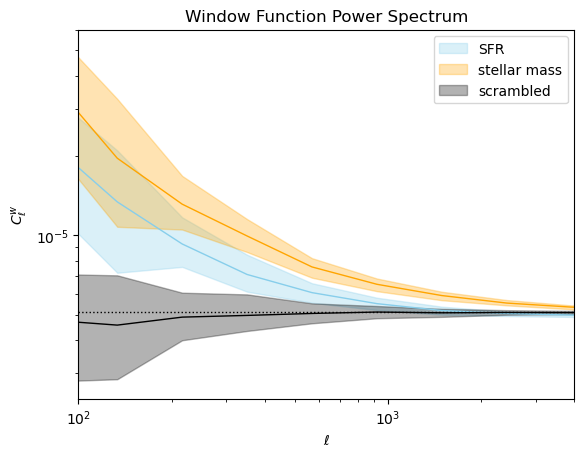

In [18]:
fig, ax = plt.subplots()
fsky_fid = np.mean(w_fid)

colors = ('skyblue', 'orange', 'k')
labels = ('SFR', 'stellar mass', 'scrambled')
for i, Cls in enumerate((Clw_fid, Clw_mass, Clw_scram_fid)):
    plot_xcorr_trials(l, Cls, ax=ax, color=colors[i], label=labels[i], ylabel=r'$C_\ell^{w}$', yscale='log')
    print(f'{labels[i]}: ' + r'$\sum C_\ell^w = ' + f'{np.mean([np.sum(Cl_*mlambda) for Cl_ in Cls])}$')
ax.axhline(s**2/fsky_fid - s**2, ls=':', color='k', lw=1)
ax.set_ylabel(r'$C_\ell^{w}$')
ax.set_title('Window Function Power Spectrum')
ax.set_ylim(top=6e-5)
ax.legend()

In [19]:
Clw_fid_mean, Clw_mass_mean = np.mean(Clw_fid, axis=0), np.mean(Clw_mass, axis=0)

In [20]:
# theoretical sum(C_ell)

for label, ws in zip(('SFR', 'stellar mass', 'scrambled'), (w_fid, w_mass, w_fid)):
    fsky = np.mean(ws)
    sum_Clw = -(s*Np)**2 + s**2*(Np**2 - 1)/fsky
    print(f'{label}: ' + r'$\sum C_\ell^w = ' + f'{sum_Clw}$')

SFR: $\sum C_\ell^w = 0.07972069953126906$
stellar mass: $\sum C_\ell^w = 0.08771412489446198$
scrambled: $\sum C_\ell^w = 0.07972069953126906$


### $ C_\ell^{Dw} $

In [21]:
ClDw_fid, ClDw_mass, ClDw_scram_fid = [], [], []
for ws, ClDws in zip((w_fid, w_mass, w_scram_fid), (ClDw_fid, ClDw_mass, ClDw_scram_fid)):
    # for i, w in enumerate(ws):
    #     l, Cl = cross_power_estimator(w, midslice_DMs[int(i//5)], nbins=nbins)
    #     ClDws.append(Cl)
    for i, DM in enumerate(midslice_DMs):
        w_ = (ws[i*5] - np.mean(ws[i*5])) / np.mean(ws[i*5])   
        l, Cl = cross_power_estimator(w_, DM - np.mean(DM), nbins=nbins)
        ClDws.append(Cl)

ClDw_fid, ClDw_mass, ClDw_scram_fid = np.stack(ClDw_fid, axis=0), np.stack(ClDw_mass, axis=0), np.stack(ClDw_scram_fid, axis=0)

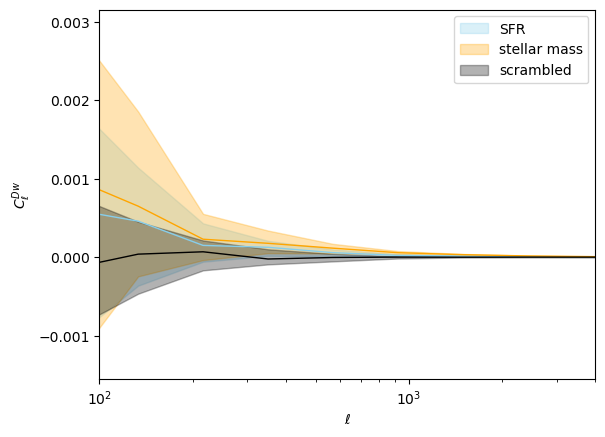

In [22]:
fig, ax = plt.subplots()

colors = ('skyblue', 'orange', 'k')
labels = ('SFR', 'stellar mass', 'scrambled')
for i, Cls in enumerate((ClDw_fid, ClDw_mass, ClDw_scram_fid)):
    plot_xcorr_trials(l, Cls, ax=ax, color=colors[i], label=labels[i], ylabel=r'$C_\ell^{Dw}$', yscale='linear')
# ax.set_ylim(top=6e-5)
ax.legend()

In [23]:
ClDw_fid_mean, ClDw_mass_mean = np.mean(ClDw_fid, axis=0), np.mean(ClDw_mass, axis=0)

### try computing Gaussian covariance

In [7]:
# # get galaxy and DM fields
# delta_gs = []
# for reg_name in sorted(regions.keys()):
#     sim = exp_simulation(500 * np.array([50, 70, 23]), reg_name)
#     N_g = sim.Ngal_grid(zrange=g_zrange)
#     delta_gs.append( (N_g - np.mean(N_g)) / np.mean(N_g) )

# delta_gs = np.stack(delta_gs, axis=0)
# np.save('/ceph/submit/data/group/submit-illustris/april/data/C_ells/delta_g_fields_z0203.npy', delta_gs)

delta_gs = np.load('/ceph/submit/data/group/submit-illustris/april/data/C_ells/delta_g_fields_z0203.npy')

In [8]:
Clggs = []
for delta_g in delta_gs:
    l, Cl = cross_power_estimator(delta_g, delta_g, nbins=nbins)
    Clggs.append(Cl)
Clgg = np.mean(np.vstack(Clggs), axis=0)

ClDDs = []
for DM in midslice_DMs:
    _, Cl = cross_power_estimator((DM - np.mean(DM)), (DM - np.mean(DM)), nbins=nbins)
    ClDDs.append(Cl)
ClDD = np.mean(np.vstack(ClDDs), axis=0)

Cl_fid, Cl_mass, Cl_scram_fid = np.stack(res['n_frbs_sfrweight'][n_frbs], axis=0), \
                                np.stack(res['n_frbs_massweight'][n_frbs], axis=0), \
                                np.stack(res['n_frbs_randpixels'][n_frbs], axis=0) # ClDg

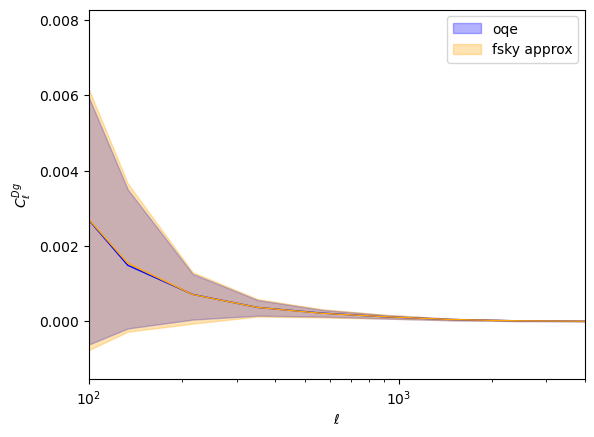

In [26]:
# showing that the OQE is the same as the fsky approximation

fig, ax = plt.subplots()
plot_xcorr_trials(ells, Cl_fid, ax=ax, color='blue', label='oqe', yscale='linear')
plot_xcorr_trials(ells, [cross_power_estimator(DM_fid[i] - np.mean(DM_fid[i]), 
                                               delta_gs[i//5], nbins=nbins)[1] / np.mean(w_fid[i]) for i in range(len(DM_fid))], 
                  ax=ax, color='orange', label='fsky approx', yscale='linear')
plt.legend()

In [27]:
def get_Clcov_from_Cls(ClDg, Clgg, ClDD, Clw, ClDw=0, s=s, Np=Np, 
                       ell_bin_edges=ell_bin_edges, mlambda=mlambda, lgrid=lgrid):
    def atleast_1d(x):
        x = np.asarray(x)
        return x if x.ndim else x*np.ones_like(Clgg)
    
    ClDg, Clgg, ClDD, ClDw, Clw = atleast_1d(ClDg), atleast_1d(Clgg), atleast_1d(ClDD), atleast_1d(ClDw), atleast_1d(Clw)
    res = (ClDg**2 + Clgg*ClDD)/mlambda # classic gaussian covariance

    # extra terms
    DDwws, DwDws = np.zeros_like(Clgg), np.zeros_like(Clgg)
    lgrid_dig = np.digitize(lgrid, ell_bin_edges)
    m = (lgrid_dig >= 1) * (lgrid_dig <= len(ell_bin_edges))
    Clw_grid, ClDD_grid, ClDw_grid = Clw[lgrid_dig - 1], ClDD[lgrid_dig - 1], ClDw[lgrid_dig - 1]
    Clw_grid[ lgrid_dig==0 ], ClDD_grid[ lgrid_dig==0 ], ClDw_grid[ lgrid_dig==0 ] = 0, 0, 0 #0 monopole
    for i in range(len(ClDg)):
        for ind in np.argwhere(lgrid_dig == i+1):
            DwDws[i] += np.sum((ClDw_grid * np.roll(ClDw_grid, -ind, axis=(0,1)))[m])
            DDwws[i] += np.sum((Clw_grid * np.roll(ClDD_grid, -ind, axis=(0,1)))[m])
    res += (DDwws + DwDws) * Clgg / (Np*s*mlambda)**2
    print(DDwws * Clgg / (Np*s*mlambda)**2, DwDws * Clgg / (Np*s*mlambda)**2)

    return res 

In [28]:
def test_covariance(ClDgs, Clw, ClDw, Clgg=Clgg, ClDD=ClDD, color='blue', ax=None):
    ClDg = np.mean(ClDgs, axis=0)
    DeltaC = np.sqrt(get_Clcov_from_Cls(ClDg, Clgg, ClDD, Clw, ClDw=ClDw))
    gaussian_std = np.sqrt((np.mean(Cl_scram_fid, axis=0)**2 + Clgg*ClDD)/mlambda)

    plot_xcorr_trials(ells, ClDgs, color=color, ax=ax, label='measured', ylabel=r'$C_\ell^{Dg}$', yscale='log')
    plt.plot(ells, ClDg - DeltaC, color='k', ls='--', lw=1, label='th. error with w')
    plt.plot(ells, ClDg + DeltaC, color='k', ls='--', lw=1)
    plt.plot(ells, ClDg - gaussian_std, color='pink', ls='--', lw=1, label='th. error')
    plt.plot(ells, ClDg + gaussian_std, color='pink', ls='--', lw=1)

    plt.legend()

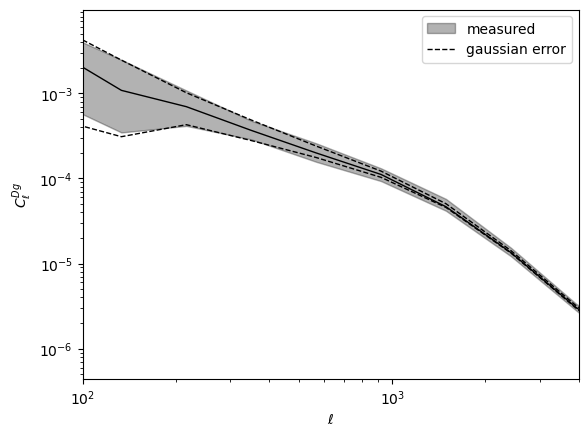

In [9]:
# first test without sky mask

midslice_ClDgs = res['midslice']['ClDg']
midslice_ClDDs = [cross_power_estimator(midslice_DMs[i] - np.mean(midslice_DMs[i]), 
                                        midslice_DMs[i] - np.mean(midslice_DMs[i]), nbins=nbins)[1] for i in range(len(midslice_DMs))]
midslice_ClDg, midslice_ClDD = np.mean(np.vstack(midslice_ClDgs), axis=0), np.mean(np.vstack(midslice_ClDDs), axis=0)
DeltaC = np.sqrt((midslice_ClDg**2 + Clgg*midslice_ClDD)/mlambda)

plot_xcorr_trials(ells, midslice_ClDgs, label='measured', ylabel=r'$C_\ell^{Dg}$', yscale='log')
plt.plot(ells, midslice_ClDg - DeltaC, color='k', ls='--', lw=1, label='gaussian error')
plt.plot(ells, midslice_ClDg + DeltaC, color='k', ls='--', lw=1)
plt.legend()

[2.91960560e-07 9.81888888e-08 1.42273565e-08 3.45912750e-09
 6.81202023e-10 1.35321738e-10 2.48240241e-11 3.55320557e-12
 8.57181684e-13 8.35150479e-12] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'scrambled')

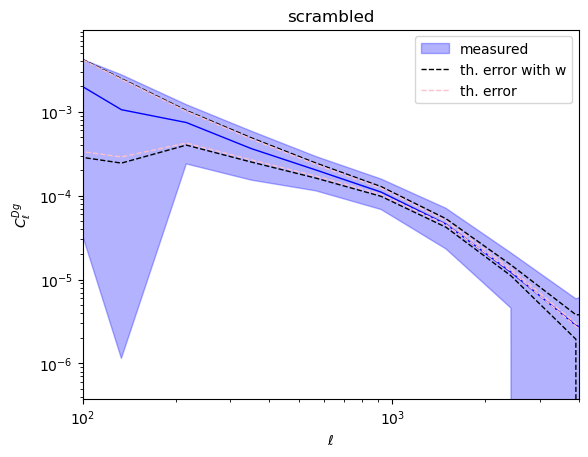

In [29]:
# let's try scrambled first

test_covariance(Cl_scram_fid, s**2/fsky_fid - s**2, 0)
plt.title('scrambled')

[4.41399515e-07 1.44260856e-07 1.93543524e-08 4.33527971e-09
 7.88735020e-10 1.46472379e-10 2.55282760e-11 3.53678194e-12
 8.41064255e-13 8.14919786e-12] [3.45039022e-09 1.07265502e-09 1.34419130e-10 2.59271302e-11
 3.75731895e-12 5.10915599e-13 6.36579786e-14 5.86963080e-15
 9.23754721e-16 7.27599827e-15]


Text(0.5, 1.0, 'fiducial')

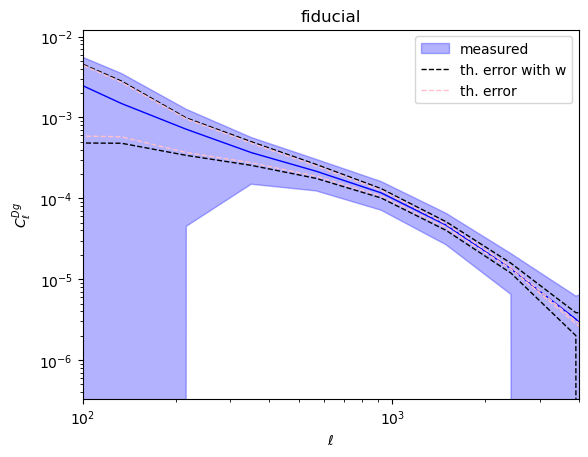

In [31]:
test_covariance(Cl_fid, Clw_fid_mean, ClDw_fid_mean)
plt.title('fiducial')

### legacy: Power spectrum with overlapping FRBs and galaxies

We observe a power spectrum which increases as the host galaxy redshift range intersects with the galaxy redshift range. The increasing power spectrum has to be for a similar reason as above, i.e. it is a consequence of the window function. It cannot be due to a redshift evolution of $P_{ge}$, since the DM-galaxy cross-correlation simply measures $P_{ge}$ at the redshift of the galaxies, which is fixed. See Eq. 2 of [Madhavachderil+ 2019](https://arxiv.org/pdf/1901.02418).

We have host galaxies with $z_\text{min} < z_\text{host} < 0.4$ and galaxies with $0.2 < z_g < 0.3$. When $z_\text{min} \lesssim 0.25$, we have FRBs which do not contribute to the signal. Then, our measured DM field is
$$\widetilde{D} = \widetilde{w_- D_-} + \widetilde{w_+ D_+} $$
where $-$ and $+$ indicate the DMs (and corresponding window function) for FRBs with $z < 0.25$ and $z > 0.25$, respectively. The total window function is $w = w_- + w_+$. The power spectrum we measure then involves the three-point correlation function:
$$\langle \widetilde{wD}_{mn} \widetilde{\delta^g}_{mn} \rangle = \frac{1}{N_p^2} \sum_{M=0}^{N_p-1}\sum_{N=0}^{N_p-1} \langle \widetilde{w}_{(m-M)(n-N)} \widetilde{D}_{MN} \widetilde{\delta^g}_{mn} \rangle = f \langle \widetilde{D}_{mn} \widetilde{\delta^g}_{mn} \rangle + \frac{f}{N_p^2} \sum_{M,N} \langle \widetilde{\delta^w}_{(m-M)(n-N)} \widetilde{d}_{MN} \widetilde{\delta^g}_{mn} \rangle$$
where $f = \overline{w}$ is the fractional sky coverage. **Assuming that $w$ can be treated as a Gaussian random field**, the second terms drops out.

With this assumption, in the overlap case, our measured power spectrum is
$$\langle \hat{C}_\ell^{Dg} \rangle = \frac{A}{f} \langle \widetilde{wD} \widetilde{\delta^g} \rangle = \frac{A}{f} \left( f_- \langle \widetilde{D_-} \widetilde{\delta^g} \rangle + f_+\langle \widetilde{D_+} \widetilde{\delta^g} \rangle \right)$$
and because $D_-$ is not correlated with the galaxies (FRBs are in the foreground of the galaxies, in this case), we end up with 
$$ \langle \hat{C}_\ell^{Dg} \rangle = \frac{f_+}{f} C_\ell^{Dg} $$

This would imply that the power spectrum gets smaller. **However, this is not the case.** The only explanation, then, is that one or more of the fields (most likely the window function) is non-Gaussian enough for a non-trivial three-point correlation. I will demonstrate that a mask that is correlated will lead to a biased measurement of the power spectrum, by measuring the galaxy auto-power spectrum without a mask, with a randomly drawn mask, and with a mask correlated with galaxies.

In [41]:
mock_fsky = 0.2
mock_w_0203 = np.random.random(delta_gs.shape) <= mock_fsky * (delta_gs + 1)
mock_w_rand = np.random.random(delta_gs.shape) <= mock_fsky

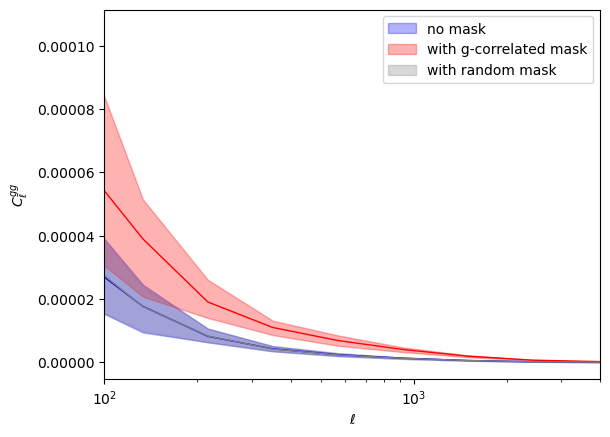

In [45]:
fig, ax = plt.subplots()
plot_xcorr_trials(ells, Clggs, ax=ax, color='blue', label='no mask')

Clggs_mock_gmask = []
for i, delta_g in enumerate(delta_gs):
    Clggs_mock_gmask.append(cross_power_estimator(mock_w_0203[i]*delta_g, delta_g, nbins=nbins)[1] / np.mean(mock_w_0203[i]))
plot_xcorr_trials(ells, Clggs_mock_gmask, ax=ax, color='red', label='with g-correlated mask')

Clggs_mock_randmask = []
for i, delta_g in enumerate(delta_gs):
    Clggs_mock_randmask.append(cross_power_estimator(mock_w_rand[i]*delta_g, delta_g, nbins=nbins)[1] / np.mean(mock_w_rand[i]))
plot_xcorr_trials(ells, Clggs_mock_randmask, ax=ax, color='gray', label='with random mask', ylabel=r'$C_\ell^{gg}$')

plt.legend()

# investigating new data

from `runinvestigation.py`

In [5]:
new_res_path = '/ceph/submit/data/group/submit-illustris/april/data/C_ells/trial_investigation_DMs.pkl'
with open(new_res_path, 'rb') as f:
    new_res = pickle.load(f)
print(list(new_res.keys()))

['frb_zranges', 'g_zranges']


In [6]:
z = np.linspace(0.01, 0.5, 100000)
x1z = sim.comoving_distance(z) * (1 + z)
z_from_x1z = interp1d(x1z, z)

In [7]:
def get_mean_DM_x(DM, x1z, mask=True):
    if type(DM) == list:
        DM = np.stack(DM, axis=0)
    if type(x1z) == list:
        x1z = np.stack(x1z, axis=0)
    k = np.sum(DM[mask]) / np.sum(x1z[mask])
    return k * x1z

def Cls_from_fields(DMs, delta_gs, ntrials=1, mults=None, mean_DMs=None, nbins=nbins):
    Cls = []
    if mean_DMs is None:
        mean_DMs = np.mean(DMs, axis=(1,2))
    for i, DM in enumerate(DMs):
        ells, Cl = cross_power_estimator(DM - mean_DMs[i], delta_gs[i//ntrials], nbins=nbins)
        if mults is None:
            Cls.append(Cl)
        else:
            Cls.append(Cl / np.mean(mults[i]))
    return ells, np.vstack(Cls)

2115484


Text(0.5, 1.0, 'Macquart relation')

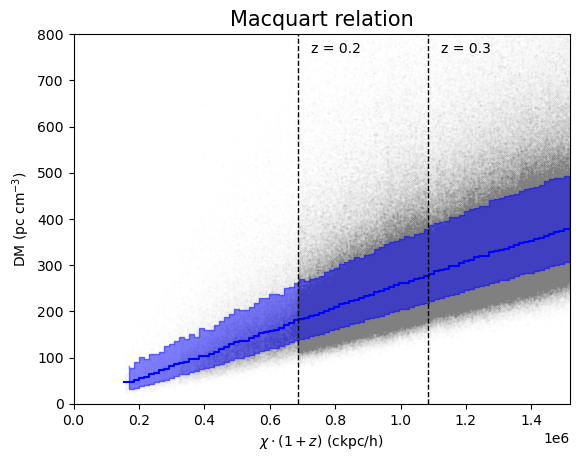

In [36]:
# plot MacQuart relation

all_DMs, all_x1zs = [], []
for zrange in new_res['frb_zranges'].keys():
    subdict = new_res['frb_zranges'][zrange]
    for i in range(len(subdict['DM_trial'])):
        all_DMs.append(subdict['DM_trial'][i][ subdict['mult_trial'][i] > 0 ])
        all_x1zs.append(subdict['x1z_trial'][i][ subdict['mult_trial'][i] > 0 ])
all_DMs, all_x1zs = np.concatenate(all_DMs).flatten(), np.concatenate(all_x1zs).flatten()
print(len(all_DMs))

plt.scatter(all_x1zs, all_DMs, s=0.1, alpha=0.01, color='gray')
plt.xlabel(r'$\chi\cdot(1+z)$ (ckpc/h)')
plt.ylabel('DM (pc cm$^{-3}$)')

# overplot binned
bins = np.linspace(0, np.amax(all_x1zs), 100)
DM_mid, _, _ = binned_statistic(all_x1zs, all_DMs, statistic='median', bins=bins)
DM_low, _, _ = binned_statistic(all_x1zs, all_DMs, statistic=lambda x: np.percentile(x, 16), bins=bins)
DM_high, _, _ = binned_statistic(all_x1zs, all_DMs, statistic=lambda x: np.percentile(x, 84), bins=bins)
plt.step(bins[1:], DM_mid, where='pre', color='b')
plt.fill_between(bins[1:], DM_low, DM_high, alpha=0.5, step='pre', color='b')

ymax = 800
plt.xlim(0, np.amax(all_x1zs))
plt.ylim(0, ymax)

for z in (0.2, 0.3):
    plt.axvline(sim.comoving_distance(z) * (1 + z), color='k', ls='--', lw=1)
    plt.text(sim.comoving_distance(z) * (1 + z) + 4e4, ymax*19/20, f'z = {z}', fontsize=10)

plt.title('Macquart relation', fontsize=15)

### varying FRB redshift range

In [8]:
g_zrange = (0.2, 0.3)
delta_gs = new_res['g_zranges'][g_zrange]

Cl, Cl_mcq, Cl_midslice = {}, {}, {}
for zrange in new_res['frb_zranges'].keys():
    subdict = new_res['frb_zranges'][zrange]
    DM_midslice, DM, x1z, mult = np.stack(subdict['DM_midslice'], axis=0), \
                    np.stack(subdict['DM_trial'], axis=0), \
                    np.stack(subdict['x1z_trial'], axis=0), \
                    np.stack(subdict['mult_trial'], axis=0)
    ells, Cl_mcq_ = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult, 
                                 mean_DMs=get_mean_DM_x(DM, x1z, mult > 0))
    ells, Cl_ = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult)
    ells, Cl_midslice_ = Cls_from_fields(DM_midslice, delta_gs)
    Cl[zrange], Cl_mcq[zrange], Cl_midslice[zrange] = Cl_, Cl_mcq_, Cl_midslice_

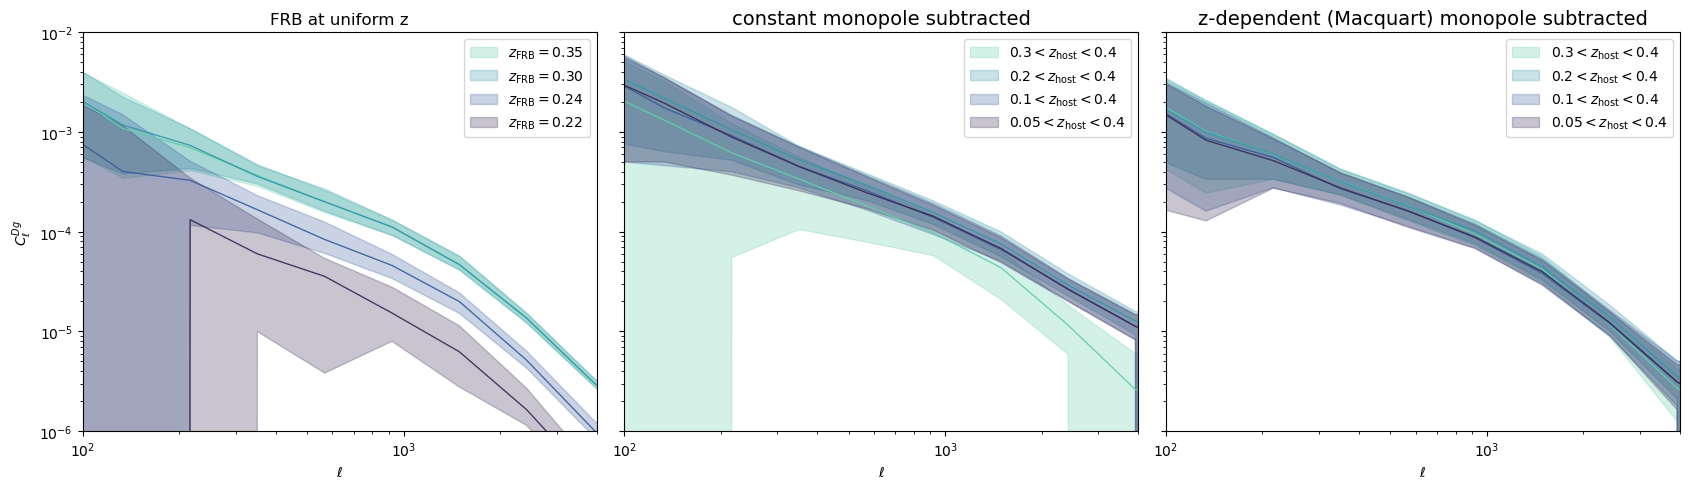

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
subplot_from_dict(ells, Cl_midslice, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: r'$z_\text{FRB} = ' + f'{sim.z_from_dist(np.mean(sim.comoving_distance(x))):.2f}$', 
                      colors=mako, ax=axes[0], legend=True)
axes[0].set_title('FRB at uniform z')
axes[0].set_ylim(1e-6, 1e-2)

titles = ['constant monopole subtracted', 'z-dependent (Macquart) monopole subtracted']
for i, Cldict in enumerate([Cl, Cl_mcq]):
    ax = axes[i+1]
    subplot_from_dict(ells, Cldict, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                      colors=mako, ax=ax, legend=True, ylabel='')
    # Cl0203_low = np.percentile(Cldict[(0.2, 0.3)], 16, axis=0)
    # Cl0203_high = np.percentile(Cldict[(0.2, 0.3)], 84, axis=0)
    # ax.plot(ells, Cl0203_low, color='k', ls='--', lw=1, label=r'$0.2 < z_\text{host} < 0.3$')
    # ax.plot(ells, Cl0203_high, color='k', ls='--', lw=1)
    ax.set_title(titles[i], fontsize=14)
plt.tight_layout()

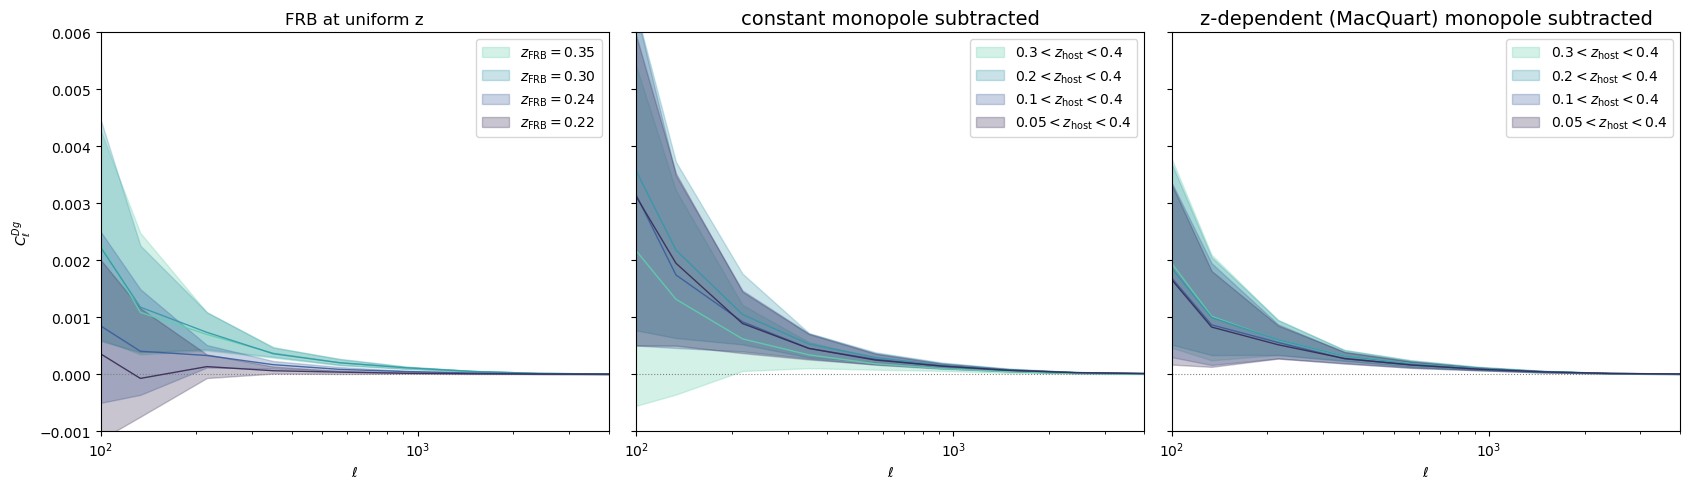

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
subplot_from_dict(ells, Cl_midslice, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: r'$z_\text{FRB} = ' + f'{sim.z_from_dist(np.mean(sim.comoving_distance(x))):.2f}$', 
                      colors=mako, ax=axes[0], yscale='linear', legend=True)
axes[0].set_title('FRB at uniform z')
axes[0].set_ylim(-0.001, 0.006)

titles = ['constant monopole subtracted', 'z-dependent (Macquart) monopole subtracted']
for i, Cldict in enumerate([Cl, Cl_mcq]):
    ax = axes[i+1]
    subplot_from_dict(ells, Cldict, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                      colors=mako, ax=ax, legend=True, ylabel='', yscale='linear')
    ax.set_title(titles[i], fontsize=14)
plt.tight_layout()

In [10]:
# try just subtracting the mean DM in chunks

def get_mean_DM_chunk(DM, x1z, mask, zranges = [(0, g_zrange[0]), (g_zrange[0], g_zrange[1]), (g_zrange[1], 1)]):
    mean_DM = np.zeros_like(DM)
    z =  np.zeros_like(x1z)
    z[mask] = z_from_x1z(x1z[mask])
    for zrange in zranges:
        mask_ = mask & (z > zrange[0]) & (z <= zrange[1])
        if np.any(mask_):
            mean_DM[mask_] = np.mean(DM[mask_])
    return mean_DM


Cl_zchunk = {}
for zrange in new_res['frb_zranges'].keys():
    subdict = new_res['frb_zranges'][zrange]
    DM, x1z, mult = np.stack(subdict['DM_trial'], axis=0), \
                    np.stack(subdict['x1z_trial'], axis=0), \
                    np.stack(subdict['mult_trial'], axis=0)
    Cl_zchunk[zrange] = Cls_from_fields(DM, delta_gs, ntrials=ntrials, mults=mult, 
                                        mean_DMs=get_mean_DM_chunk(DM, x1z, mult > 0))[1]

In [17]:
Cl_zchunk_corrected = {}
for key in [(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)]:
    mask = np.stack( new_res['frb_zranges'][key]['mult_trial'], axis=0 ) > 0
    x1z = np.stack( new_res['frb_zranges'][key]['x1z_trial'], axis=0 )
    z = np.zeros_like(x1z)
    z[mask] = z_from_x1z(x1z[mask])
    f0 = np.mean((z > g_zrange[0]) & (z <= g_zrange[1]), axis=(1,2))
    f1 = np.mean((z > g_zrange[1]), axis=(1,2))
    f = np.mean(mask, axis=(1,2))
    Cl_zchunk_corrected[key] = Cl_zchunk[key] / np.atleast_2d((0.5*f0 + f1)/f).T

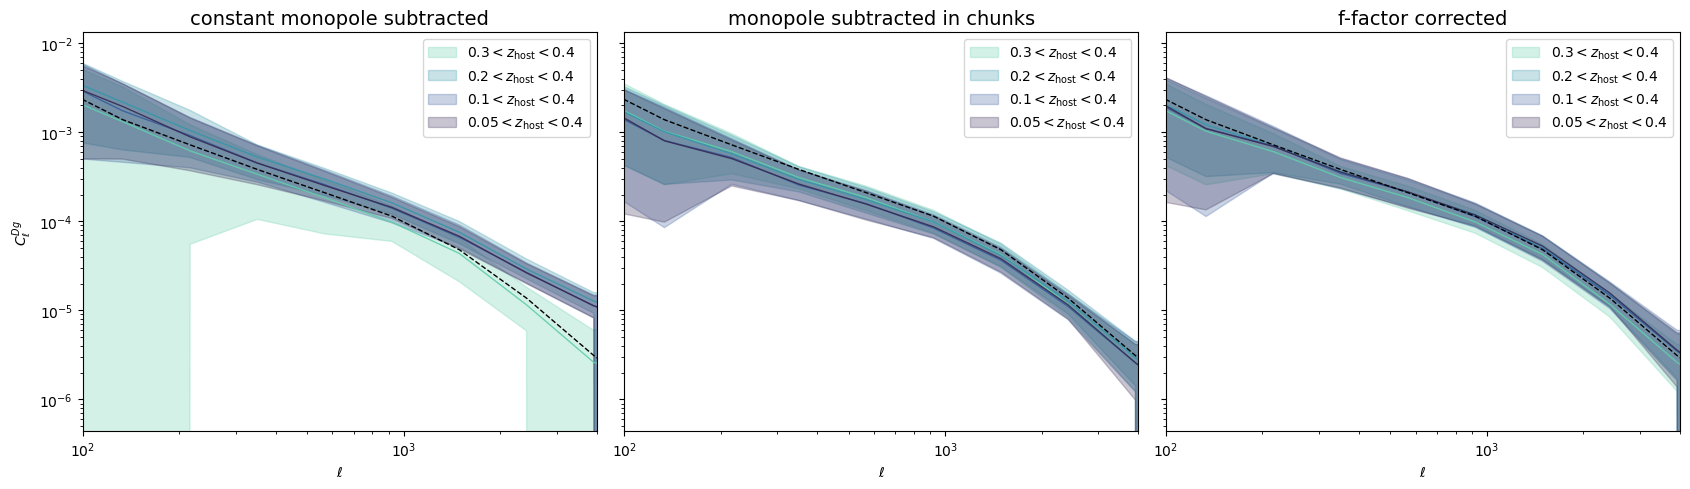

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)

ref_Cls = np.mean(Cl_midslice[(0.3, 0.4)], axis=0)

titles = ['constant monopole subtracted', 'monopole subtracted in chunks', 'f-factor corrected']
for i, Cldict in enumerate([Cl, Cl_zchunk, Cl_zchunk_corrected]):
    ax = axes[i]
    subplot_from_dict(ells, Cldict, whichkeys=[(0.3, 0.4), (0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_\text{host}' + f' < {x[1]}$', 
                      colors=mako, ax=ax, legend=True)
    if i > 0:
        ax.set_ylabel('')
    ax.plot(ells, ref_Cls, color='k', ls='--', lw=1)
    ax.set_title(titles[i], fontsize=14)
plt.tight_layout()

### varying galaxy redshift range

mean DM: 305
std DM: 135


(0.05, 0.4)

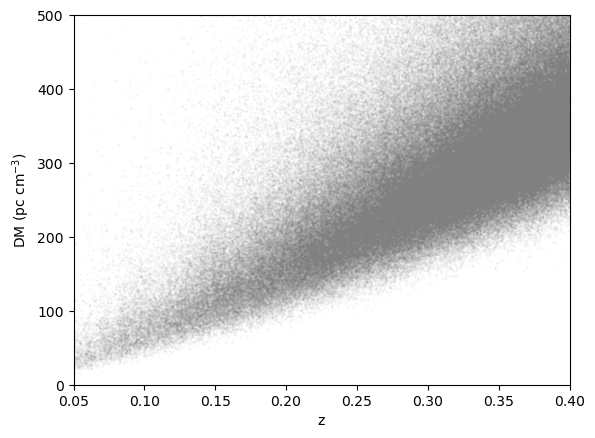

In [25]:
DM, x1z, mult = np.stack(new_res['frb_zranges'][(0.05, 0.4)]['DM_trial'], axis=0), \
                np.stack(new_res['frb_zranges'][(0.05, 0.4)]['x1z_trial'], axis=0), \
                np.stack(new_res['frb_zranges'][(0.05, 0.4)]['mult_trial'], axis=0)
mean_DMs = get_mean_DM_x(DM, x1z, mult > 0)

print(f'mean DM: {np.mean(DM[mult > 0]):.0f}')
print(f'std DM: {np.std(DM[mult > 0]):.0f}')
plt.scatter(z_from_x1z(x1z[mult > 0]), DM[mult > 0], s=0.1, alpha=0.1, color='gray')
plt.xlabel('z')
plt.ylabel('DM (pc cm$^{-3}$)')
plt.ylim(0, 500)
plt.xlim(0.05, 0.4)

mean DM: 35
std DM: 108


In [ ]:
Cl_var_zg, Cl_var_zg_mcq = {}, {}
for zrange in new_res['g_zranges'].keys():
    delta_gs_ = new_res['g_zranges'][zrange]
    ells, Cl_mcq_ = Cls_from_fields(DM, delta_gs_, ntrials=ntrials, mults=mult, mean_DMs=mean_DMs)
    ells, Cl_ = Cls_from_fields(DM, delta_gs_, ntrials=ntrials, mults=mult)
    Cl_var_zg[zrange], Cl_var_zg_mcq[zrange] = Cl_, Cl_mcq_

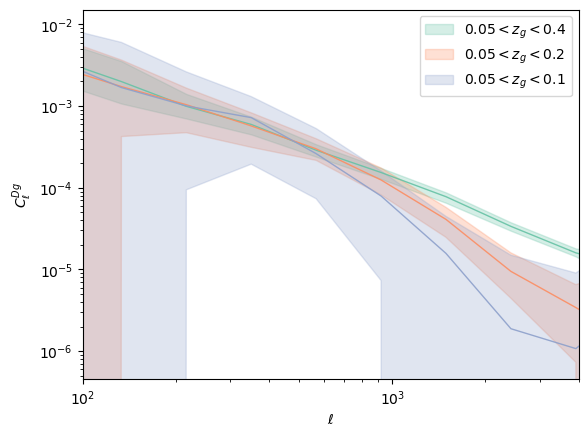

In [48]:
set2 = sns.color_palette("Set2")
subplot_from_dict(ells, Cl_var_zg, whichkeys=[(0.05, 0.4), (0.05, 0.2), (0.05, 0.1)],
                  labels=lambda x: f'${x[0]} < ' + r'z_g' + f' < {x[1]}$', 
                  colors=set2)

(-0.001, 0.006)

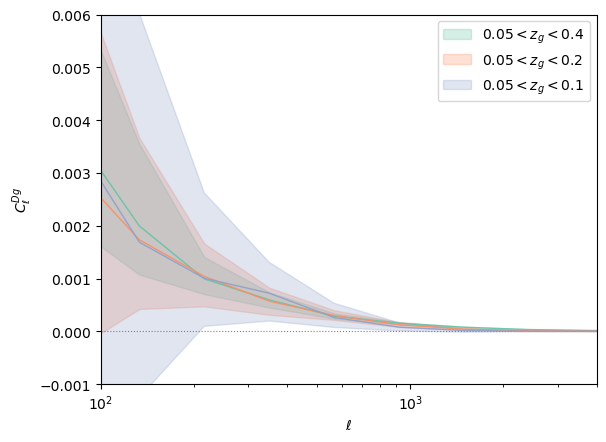

In [49]:
set2 = sns.color_palette("Set2")
subplot_from_dict(ells, Cl_var_zg, whichkeys=[(0.05, 0.4), (0.05, 0.2), (0.05, 0.1)],
                  labels=lambda x: f'${x[0]} < ' + r'z_g' + f' < {x[1]}$', 
                  colors=set2, yscale='linear')
plt.ylim(-0.001, 0.006)

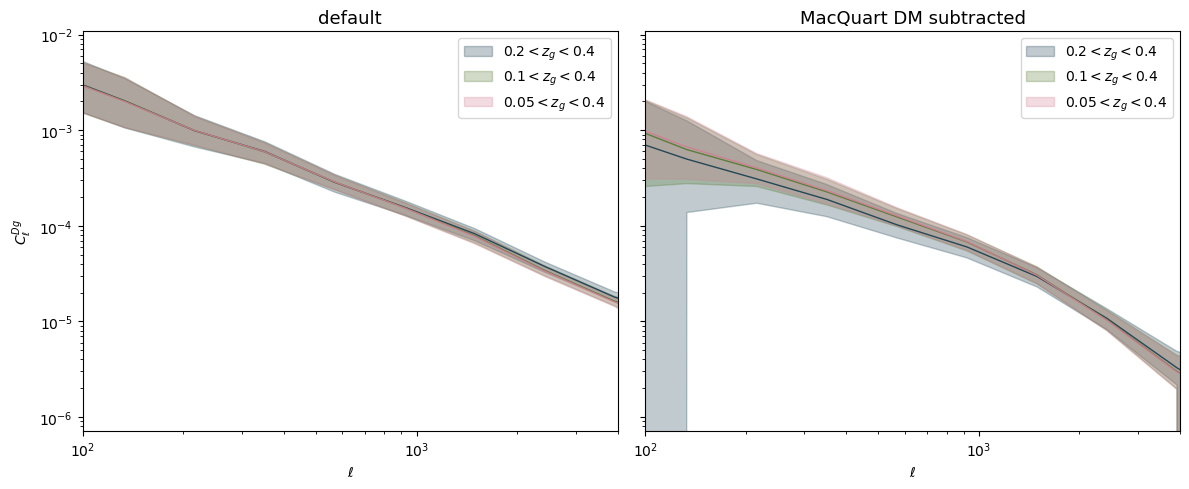

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
titles = ['default', 'MacQuart DM subtracted']
for i, Cldict in enumerate([Cl_var_zg, Cl_var_zg_mcq]):
    ax = axes[i]
    subplot_from_dict(ells, Cldict, whichkeys=[(0.2, 0.4), (0.1, 0.4), (0.05, 0.4)],
                      labels=lambda x: f'${x[0]} < ' + r'z_g' + f' < {x[1]}$', 
                      colors=cubehelix, ax=ax)
    # Cl0203_low = np.percentile(Cldict[(0.2, 0.3)], 16, axis=0)
    # Cl0203_high = np.percentile(Cldict[(0.2, 0.3)], 84, axis=0)
    # ax.plot(ells, Cl0203_low, color='k', ls='--', lw=1, label=r'$0.2 < z_g < 0.3$')
    # ax.plot(ells, Cl0203_high, color='k', ls='--', lw=1)
    ax.set_title(titles[i], fontsize=13)
    if i > 0:
        ax.set_ylabel('')
plt.tight_layout()

In [44]:
new_res['g_zranges'].keys()

dict_keys([(0.2, 0.4), (0.1, 0.4), (0.05, 0.4)])